In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv('voice.csv')

# Pisahkan feature dan label
X = df.drop('label', axis=1)
y = df['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.9810725552050473


In [3]:
results = {}

for feature in X.columns:
    knn = KNeighborsClassifier(n_neighbors=5)

    knn.fit(X_train[:, [X.columns.get_loc(feature)]], y_train)

    y_pred = knn.predict(X_test[:, [X.columns.get_loc(feature)]])

    results[feature] = accuracy_score(y_test, y_pred)

results = pd.Series(results).sort_values(ascending=False)

print(results)

meanfun     0.949527
IQR         0.906940
Q25         0.883281
sd          0.802839
sp.ent      0.731861
sfm         0.690852
mode        0.664038
maxdom      0.635647
centroid    0.621451
meanfreq    0.621451
dfrange     0.607256
median      0.599369
skew        0.588328
meandom     0.580442
mindom      0.563091
kurt        0.536278
Q75         0.531546
minfun      0.528391
maxfun      0.525237
modindx     0.504732
dtype: float64


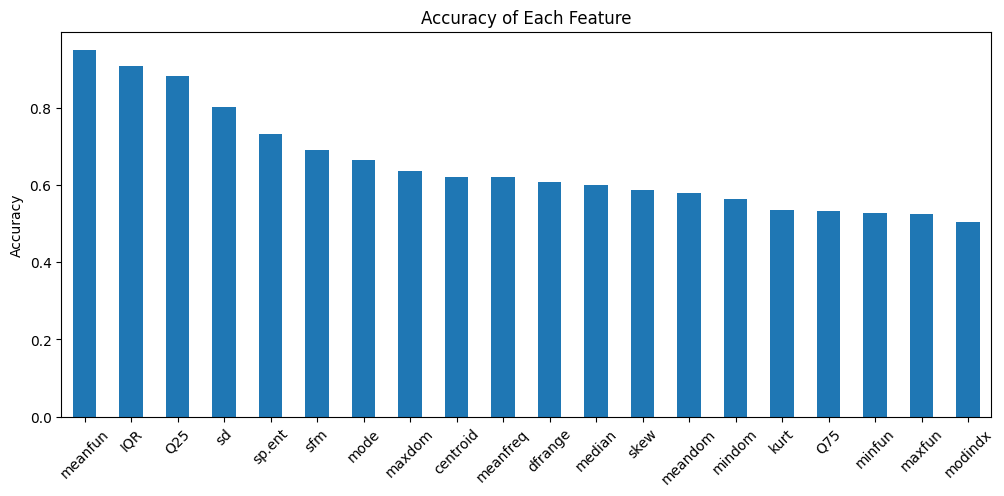

In [4]:
results.plot(kind='bar', figsize=(12, 5))

plt.ylabel('Accuracy')
plt.title('Accuracy of Each Feature')
plt.xticks(rotation=45)
plt.show()

In [5]:
best_feature = results.index[0]

print('Best feature:', best_feature)
print('Accuracy:', results.iloc[0])

Best feature: meanfun
Accuracy: 0.9495268138801262


In [6]:
feature_index = X.columns.get_loc(best_feature)

X_train_best = X_train[:, [feature_index]]
X_test_best = X_test[:, [feature_index]]

accuracies = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_best, y_train)

    y_pred = knn.predict(X_test_best)

    accuracies.append(accuracy_score(y_test, y_pred))

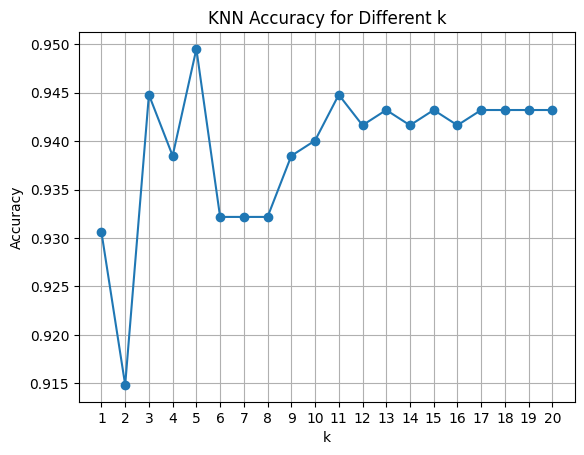

In [7]:
plt.plot(range(1, 21), accuracies, marker='o')

plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k')
plt.xticks(range(1, 21))
plt.grid()
plt.show()

In [8]:
best_k = accuracies.index(max(accuracies)) + 1

print('Best k:', best_k)
print('Best accuracy:', max(accuracies))

Best k: 5
Best accuracy: 0.9495268138801262
